In [1]:
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os



In [33]:
# === KONFIGURATION ===

workDir = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"

# NEUER MBA-Datensatz mit allen Metriken
combined_path = os.path.join(
    workDir,
    r"_Runs\03_Woody_Fire_combined\woody_burned_MBA_full_combined.tif"
)

# NEUER Ecoregions Datensatz
ecoregions_shp = r"\\141.20.141.12\SAN_BioGeo\_HiWi\Ruben\thesis\data\Ecoregions\eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00\BiogeoRegions2016.shp"

# Raster & CSV Output
output_dir = os.path.join(workDir, "_Runs", "04_Ecoregions_MBA")
os.makedirs(output_dir, exist_ok=True)

# Plots and Visuals Output
visuals_dir = os.path.join(workDir, "_Runs", "04_Ecoregions_MBA", "visuals")
os.makedirs(visuals_dir, exist_ok=True)

years_woody = list(range(1985, 2025))  # 40 Jahre (1985-2024)
years_burned = list(range(2000, 2026))  # 26 Jahre (2000-2025)

print("="*70)
print("ECOREGIONS-ANALYSE MIT MBA-DATENSATZ")
print("="*70)


ECOREGIONS-ANALYSE MIT MBA-DATENSATZ


In [3]:

# === 1. SHAPEFILE LADEN ===

print("\n1. LADE ECOREGIONS SHAPEFILE")
print("-" * 70)

ecoregions_gdf = gpd.read_file(ecoregions_shp)
print(f"✓ Shapefile geladen: {ecoregions_shp}")
print(f"  Anzahl Features: {len(ecoregions_gdf)}")
print(f"  Spalten: {list(ecoregions_gdf.columns)}")
print(f"  CRS: {ecoregions_gdf.crs}")

# Zeige erste Features
print(f"\nErste 5 Ecoregions:")
print(ecoregions_gdf.head())



1. LADE ECOREGIONS SHAPEFILE
----------------------------------------------------------------------
✓ Shapefile geladen: \\141.20.141.12\SAN_BioGeo\_HiWi\Ruben\thesis\data\Ecoregions\eea_v_3035_1_mio_biogeo-regions_p_2016_v01_r00\BiogeoRegions2016.shp
  Anzahl Features: 12
  Spalten: ['PK_UID', 'short_name', 'pre_2012', 'code', 'name', 'geometry']
  CRS: PROJCS["ETRS_1989_LAEA_L52_M10",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Erste 5 Ecoregions:
   PK_UID short_name pre_2012       code                               name  \
0       1     alpine 

In [4]:

# === 2. RASTER-EIGENSCHAFTEN LADEN ===

print("\n2. LADE RASTER-EIGENSCHAFTEN")
print("-" * 70)

with rasterio.open(combined_path) as src:
    bounds = src.bounds
    crs = src.crs
    transform = src.transform
    width = src.width
    height = src.height
    total_bands = src.count
    band_descriptions = src.descriptions

print(f"✓ Raster geladen: {combined_path}")
print(f"  Bounds (EPSG:3035): {bounds}")
print(f"  Dimensionen: {width} × {height}")
print(f"  Auflösung: {transform[0]}m")
print(f"  Anzahl Bänder: {total_bands}")



2. LADE RASTER-EIGENSCHAFTEN
----------------------------------------------------------------------
✓ Raster geladen: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\03_Woody_Fire_combined\woody_burned_MBA_full_combined.tif
  Bounds (EPSG:3035): BoundingBox(left=2477500.0, bottom=1289000.0, right=7719000.0, top=6119000.0)
  Dimensionen: 10483 × 9660
  Auflösung: 500.0m
  Anzahl Bänder: 352


In [9]:

# === 3. ECOREGIONS AUF STUDIENGEBIET TRANSFORMIEREN ===

print("\n3. TRANSFORMIERE ECOREGIONS")
print("-" * 70)

if ecoregions_gdf.crs != crs:
    print(f"Transformiere von {ecoregions_gdf.crs} zu {crs}")
    ecoregions_gdf = ecoregions_gdf.to_crs(crs)
else:
    print("✓ CRS stimmt bereits überein")

# Clippe auf Studiengebiet
from shapely.geometry import box
study_bbox = box(*bounds)

print("Clippe Ecoregions auf Studiengebiet...")
ecoregions_clipped = gpd.clip(ecoregions_gdf, study_bbox)
print(f"✓ Anzahl Ecoregions im Studiengebiet: {len(ecoregions_clipped)}")



3. TRANSFORMIERE ECOREGIONS
----------------------------------------------------------------------
✓ CRS stimmt bereits überein
Clippe Ecoregions auf Studiengebiet...
✓ Anzahl Ecoregions im Studiengebiet: 11


In [10]:
print(ecoregions_clipped[['short_name', 'pre_2012', 'code', 'name']])


       short_name pre_2012           code  \
1       anatolian      ANA      Anatolian   
4        blackSea      BLS       BlackSea   
11        steppic      STE        Steppic   
6     continental      CON    Continental   
0          alpine      ALP         Alpine   
5          boreal      BOR         Boreal   
8   mediterranean      MED  Mediterranean   
10      pannonian      PAN      Pannonian   
3        atlantic      ATL       Atlantic   
9         outside      OUT        Outside   
2          arctic      ARC         Arctic   

                                     name  
1       Anatolian Bio-geographical Region  
4       Black Sea Bio-geographical Region  
11        Steppic Bio-geographical Region  
6     Continental Bio-geographical Region  
0          Alpine Bio-geographical Region  
5          Boreal Bio-geographical Region  
8   Mediterranean Bio-geographical Region  
10      Pannonian Bio-geographical Region  
3        Atlantic Bio-geographical Region  
9                  

In [11]:

# === 4. ATTRIBUTE AUSWÄHLEN ===

print("\n4. WÄHLE ATTRIBUTE")
print("-" * 70)

# Verfügbare Spalten anzeigen
print(f"Verfügbare Spalten: {list(ecoregions_clipped.columns)}")

# Typische Attribute für EEA Biogeographical Regions
# Passe diese basierend auf tatsächlichen Spalten an
possible_id_cols = ['code', 'CODE', 'region_id', 'REGION_ID', 'FID', 'OBJECTID']
possible_name_cols = ['name', 'NAME', 'short_name', 'ShortName', 'region_name', 'REGION_NAM']

# Finde verfügbare ID-Spalte
id_column = None
for col in possible_id_cols:
    if col in ecoregions_clipped.columns:
        id_column = col
        break

# Finde verfügbare Name-Spalte
name_column = None
for col in possible_name_cols:
    if col in ecoregions_clipped.columns:
        name_column = col
        break

if id_column is None:
    # Fallback: erstelle eigene IDs
    ecoregions_clipped['ECO_ID'] = range(1, len(ecoregions_clipped) + 1)
    id_column = 'ECO_ID'
    print(f"⚠ Keine ID-Spalte gefunden, erstelle eigene: {id_column}")
else:
    print(f"✓ Verwende ID-Spalte: {id_column}")

if name_column is None:
    ecoregions_clipped['ECO_NAME'] = [f"Region_{i}" for i in range(1, len(ecoregions_clipped) + 1)]
    name_column = 'ECO_NAME'
    print(f"⚠ Keine Name-Spalte gefunden, erstelle eigene: {name_column}")
else:
    print(f"✓ Verwende Name-Spalte: {name_column}")

# Konvertiere IDs zu numerischen Werten falls nötig
if ecoregions_clipped[id_column].dtype == 'object':
    print(f"Konvertiere {id_column} zu numerischen Werten...")
    ecoregions_clipped['NUMERIC_ID'] = pd.factorize(ecoregions_clipped[id_column])[0] + 1
    numeric_id_col = 'NUMERIC_ID'
else:
    numeric_id_col = id_column

print(f"\nEcoregions im Studiengebiet:")
for idx, row in ecoregions_clipped.iterrows():
    print(f"  ID {row[numeric_id_col]}: {row[name_column]}")

# === 5. RASTERISIERUNG ===

print("\n5. RASTERISIERE ECOREGIONS")
print("-" * 70)

print("Erstelle Ecoregions-Raster...")
eco_raster = rasterize(
    [(geom, value) for geom, value in zip(
        ecoregions_clipped.geometry, 
        ecoregions_clipped[numeric_id_col]
    )],
    out_shape=(height, width),
    transform=transform,
    fill=0,  # NoData
    dtype='uint16'
)

print(f"✓ Raster erstellt: {eco_raster.shape}")
print(f"  Unique IDs: {np.unique(eco_raster[eco_raster > 0])}")

# Speichere Ecoregions-Raster
eco_raster_path = os.path.join(output_dir, "ecoregions_500m_3035_MBA.tif")
with rasterio.open(
    eco_raster_path,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='uint16',
    crs=crs,
    transform=transform,
    compress='lzw',
    nodata=0
) as dst:
    dst.write(eco_raster, 1)
    dst.set_band_description(1, 'Ecoregion_ID')

print(f"✓ Ecoregions-Raster gespeichert: {eco_raster_path}")

# Speichere Attribut-Tabelle
csv_path = os.path.join(output_dir, "ecoregions_attributes.csv")
ecoregions_clipped[[numeric_id_col, name_column]].to_csv(csv_path, index=False)
print(f"✓ Attribut-Tabelle gespeichert: {csv_path}")



4. WÄHLE ATTRIBUTE
----------------------------------------------------------------------
Verfügbare Spalten: ['PK_UID', 'short_name', 'pre_2012', 'code', 'name', 'geometry']
✓ Verwende ID-Spalte: code
✓ Verwende Name-Spalte: name
Konvertiere code zu numerischen Werten...

Ecoregions im Studiengebiet:
  ID 1: Anatolian Bio-geographical Region
  ID 2: Black Sea Bio-geographical Region
  ID 3: Steppic Bio-geographical Region
  ID 4: Continental Bio-geographical Region
  ID 5: Alpine Bio-geographical Region
  ID 6: Boreal Bio-geographical Region
  ID 7: Mediterranean Bio-geographical Region
  ID 8: Pannonian Bio-geographical Region
  ID 9: Atlantic Bio-geographical Region
  ID 10: outside Europe
  ID 11: Arctic Bio-geographical Region

5. RASTERISIERE ECOREGIONS
----------------------------------------------------------------------
Erstelle Ecoregions-Raster...
✓ Raster erstellt: (9660, 10483)
  Unique IDs: [ 1  2  3  4  5  6  7  8  9 10 11]
✓ Ecoregions-Raster gespeichert: \\141.20.140.

In [40]:
# === 5a. ERWEITERTE ATTRIBUT-TABELLE MIT FARBEN (KORRIGIERT) ===

print("\n5. SPEICHERE ERWEITERTE ATTRIBUT-TABELLE MIT FARBEN")
print("-" * 70)

# Offizielle EEA Farbpalette
ECOREGION_COLORS = {
    'ALP': '#e8a197',
    'ANA': '#df826d',
    'ARC': '#bbe4e7',
    'ATL': '#0075a5',
    'BLS': '#f3c6af',
    'BOR': '#00668e',
    'CON': '#738b54',
    'MED': '#f7b916',
    'PAN': '#9c6d48',
    'STE': '#fedfac',
    'OUT': '#dcddde'
}

# Füge Farben zur Attribut-Tabelle hinzu
ecoregions_clipped['hex_color'] = ecoregions_clipped['pre_2012'].map(ECOREGION_COLORS)

# Prüfe, ob es fehlende Farben gibt
missing_colors = ecoregions_clipped[ecoregions_clipped['hex_color'].isna()]['pre_2012'].unique()
if len(missing_colors) > 0:
    print(f"⚠️  WARNUNG: Fehlende Farben für Codes: {missing_colors}")
    print("   Verwende Standard-Grau (#808080) für fehlende Codes")
    ecoregions_clipped['hex_color'] = ecoregions_clipped['hex_color'].fillna('#808080')

# Konvertiere Hex zu RGB (für GIS-Software)
def hex_to_rgb(hex_color):
    """Konvertiert Hex-Farbe zu RGB-Tupel"""
    if pd.isna(hex_color):
        return (128, 128, 128)  # Standard-Grau für fehlende Werte
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

# Sicher RGB-Werte extrahieren
ecoregions_clipped['rgb_r'] = ecoregions_clipped['hex_color'].apply(lambda x: hex_to_rgb(x)[0])
ecoregions_clipped['rgb_g'] = ecoregions_clipped['hex_color'].apply(lambda x: hex_to_rgb(x)[1])
ecoregions_clipped['rgb_b'] = ecoregions_clipped['hex_color'].apply(lambda x: hex_to_rgb(x)[2])

# Speichere erweiterte Attribut-Tabelle
csv_extended = os.path.join(output_dir, "ecoregions_attributes_with_colors.csv")
ecoregions_clipped[[numeric_id_col, 'code', 'pre_2012', name_column, 'hex_color', 'rgb_r', 'rgb_g', 'rgb_b']].to_csv(
    csv_extended, index=False
)
print(f"✓ Erweiterte Attribut-Tabelle gespeichert: {csv_extended}")

# Zeige Vorschau
print("\nAttribut-Tabelle mit Farben:")
print(ecoregions_clipped[['code', 'pre_2012', name_column, 'hex_color', 'rgb_r', 'rgb_g', 'rgb_b']].head(10))

# Zeige Statistik
print(f"\nFarbzuordnung:")
print(f"  ✓ Mit Farbe: {ecoregions_clipped['hex_color'].notna().sum()} Regionen")
print(f"  ⚠️  Standard-Grau: {(ecoregions_clipped['hex_color'] == '#808080').sum()} Regionen")

# Zeige Zuordnung pre_2012 -> code
print(f"\nSpalten-Zuordnung:")
print(ecoregions_clipped[['pre_2012', 'code', name_column]].drop_duplicates().sort_values('pre_2012'))



5. SPEICHERE ERWEITERTE ATTRIBUT-TABELLE MIT FARBEN
----------------------------------------------------------------------
✓ Erweiterte Attribut-Tabelle gespeichert: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\ecoregions_attributes_with_colors.csv

Attribut-Tabelle mit Farben:
             code pre_2012                                   name hex_color  \
1       Anatolian      ANA      Anatolian Bio-geographical Region   #df826d   
4        BlackSea      BLS      Black Sea Bio-geographical Region   #f3c6af   
11        Steppic      STE        Steppic Bio-geographical Region   #fedfac   
6     Continental      CON    Continental Bio-geographical Region   #738b54   
0          Alpine      ALP         Alpine Bio-geographical Region   #e8a197   
5          Boreal      BOR         Boreal Bio-geographical Region   #00668e   
8   Mediterranean      MED  Mediterranean Bio-geographical Region   #f7b916   
10      Pannonian      PAN      Pannonian Bio-geographical R

In [ ]:

# === 6. LADE MBA-DATEN ===

print("\n6. LADE MBA-DATENSATZ")
print("-" * 70)

print("Lade Woody Cover und MBA-Metriken (kann einige Minuten dauern)...")

with rasterio.open(combined_path) as src:
    # Woody Cover Bänder (1-40)
    woody_bands = range(1, len(years_woody) + 1)
    woody = src.read(woody_bands)
    
    # MBA Burned Bänder (jedes 12. Band ab Band 41)
    # Band 41, 53, 65, ... = burned für 2000, 2001, 2002, ...
    burned_band_indices = [40 + (i * 12) + 1 for i in range(len(years_burned))]
    burned = src.read(burned_band_indices)
    
    nodata = src.nodata

print(f"✓ Woody Cover geladen: {woody.shape}")
print(f"✓ Burned Area geladen: {burned.shape}")


In [53]:

# === 7. BERECHNE TRAJEKTORIEN PRO ECOREGION ===

print("\n7. BERECHNE TRAJEKTORIEN PRO ECOREGION")
print("-" * 70)

def calc_ecoregion_trajectory(woody, burned, eco_mask, years_woody, years_burned, nodata):
    """
    Berechnet Pre-/Post-Fire Trajektorie für eine Ecoregion
    Verwendet NUR Pixel mit GENAU 1 Brandereignis
    """
    # Anzahl Brände pro Pixel
    fire_counts = np.sum(burned == 1, axis=0)
    single_fire_mask = (fire_counts == 1) & eco_mask
    
    n_pixels = np.sum(single_fire_mask)
    
    if n_pixels < 50:  # Mindestanzahl
        return None, n_pixels
    
    # Index des Brandjahres pro Pixel
    burned_year_idx = np.argmax(burned == 1, axis=0)
    
    trajectory = []
    trajectory_std = []
    
    for rel_year in range(-5, 6):  # -5 bis +5
        # Woody Band Index = Brandjahr + rel_year + Offset
        # Offset = (Jahr des ersten Brands) - (Jahr des ersten Woody Bands)
        offset = years_burned[0] - years_woody[0]  # 2000 - 1985 = 15
        woody_band = burned_year_idx + rel_year + offset -1 # offset -1 to account for time frame misalignment
        
        # Gültige Pixel für dieses Jahr
        valid_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            single_fire_mask
        )
        
        if np.sum(valid_mask) == 0:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            continue
        
        # Werte extrahieren
        y_idx, x_idx = np.where(valid_mask)
        values = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        values = values[values != nodata]
        
        if len(values) > 0:
            trajectory.append(np.nanmean(values))
            trajectory_std.append(np.nanstd(values))
        else:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
    
    return {
        'trajectory': trajectory,
        'std': trajectory_std,
        'n_pixels': n_pixels
    }, n_pixels


# Berechne für alle Ecoregions
print("\nBerechne Trajektorien...")
ecoregion_results = {}

unique_eco_ids = np.unique(eco_raster[eco_raster > 0])

for eco_id in tqdm(unique_eco_ids, desc="Ecoregions"):
    eco_mask = (eco_raster == eco_id)
    result, n_pixels = calc_ecoregion_trajectory(
        woody, burned, eco_mask, years_woody, years_burned, nodata
    )
    
    if result is not None:
        # Name aus Attributtabelle
        eco_name_row = ecoregions_clipped[ecoregions_clipped[numeric_id_col] == eco_id]
        eco_name = eco_name_row[name_column].iloc[0] if len(eco_name_row) > 0 else f"Region {eco_id}"
        
        ecoregion_results[eco_id] = {
            'name': eco_name,
            'trajectory': result['trajectory'],
            'std': result['std'],
            'n_pixels': result['n_pixels']
        }
        
        print(f"  Region {eco_id} ({eco_name}): {n_pixels} Pixel")

print(f"\n✓ {len(ecoregion_results)} Ecoregions mit ausreichend Daten")



7. BERECHNE TRAJEKTORIEN PRO ECOREGION
----------------------------------------------------------------------

Berechne Trajektorien...


Ecoregions:   9%|▉         | 1/11 [00:36<06:04, 36.43s/it]

  Region 1 (Anatolian Bio-geographical Region): 74792 Pixel


Ecoregions:  18%|█▊        | 2/11 [01:09<05:10, 34.52s/it]

  Region 2 (Black Sea Bio-geographical Region): 8342 Pixel


...

  Region 9 (Atlantic Bio-geographical Region): 37725 Pixel


Ecoregions:  91%|█████████ | 10/11 [05:36<00:33, 33.26s/it]

  Region 10 (outside Europe): 165297 Pixel


Ecoregions: 100%|██████████| 11/11 [06:09<00:00, 33.57s/it]

  Region 11 (Arctic Bio-geographical Region): 915 Pixel

✓ 11 Ecoregions mit ausreichend Daten


In [54]:
# === 8. VISUALISIERUNG MIT OFFIZIELLEN ECOREGION-FARBEN ===

print("\n8. ERSTELLE VISUALISIERUNGEN MIT OFFIZIELLEN FARBEN")
print("-" * 70)

# Offizielle EEA Farbpalette
ECOREGION_COLORS = {
    'ALP': '#e8a197',  # Alpine
    'ANA': '#df826d',  # Anatolian
    'ARC': '#bbe4e7',  # Arctic
    'ATL': '#0075a5',  # Atlantic
    'BLS': '#f3c6af',  # Black Sea
    'BOR': '#00668e',  # Boreal
    'CON': '#738b54',  # Continental
    'MED': '#f7b916',  # Mediterranean
    'PAN': '#9c6d48',  # Pannonian
    'STE': '#fedfac',  # Steppic
    'OUT': '#dcddde'   # Outside
}

# Erstelle Farb-Mapping für die Ecoregions im Datensatz
eco_colors = {}
for eco_id, data in ecoregion_results.items():
    eco_row = ecoregions_clipped[ecoregions_clipped[numeric_id_col] == eco_id]
    if len(eco_row) > 0:
        # Versuche verschiedene Spalten
        if 'pre_2012' in eco_row.columns:
            eco_code = eco_row['pre_2012'].iloc[0]
        elif 'code' in eco_row.columns:
            eco_code = eco_row['code'].iloc[0]
        elif 'short_name' in eco_row.columns:
            eco_code = eco_row['short_name'].iloc[0]
        else:
            eco_code = None
        
        # Mapping mit Fallback
        if eco_code and eco_code in ECOREGION_COLORS:
            eco_colors[eco_id] = ECOREGION_COLORS[eco_code]
            print(f"✓ {data['name']} ({eco_code}): {ECOREGION_COLORS[eco_code]}")
        else:
            eco_colors[eco_id] = '#808080'  # Fallback grau
            print(f"⚠️ {data['name']} (code='{eco_code}'): Fallback Grau #808080")
    else:
        eco_colors[eco_id] = '#808080'
        print(f"⚠️ Eco ID {eco_id}: Keine Daten gefunden, Fallback Grau")

###############################################
# Plot 1: Alle Trajektorien in einem Plot
print("\nErstelle Plot 1: Alle Trajektorien mit offiziellen Farben...")
fig, ax = plt.subplots(figsize=(14, 8))

for eco_id, data in ecoregion_results.items():
    ax.plot(
        range(-5, 6), 
        data['trajectory'], 
        marker='o', 
        linewidth=2.5, 
        label=f"{data['name']} (n={data['n_pixels']})",
        color=eco_colors[eco_id],
        alpha=0.9
    )

# Fire Event Impact Linien
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Fire Impact Year')
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7)


# Beschriftung
ax.set_xlabel('Years Relative to Fire Event (- => Before, + => After)', fontsize=12)
ax.set_ylabel('Average Woody Cover (%)', fontsize=12)
ax.set_title('Woody Cover Trajectories relative to Fire Event \nper Ecoregion\n ', 
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Zeitliche Phasen markieren
ax.annotate('Pre-Fire\nPeriod', xy=(-2.5, ax.get_ylim()[1]*0.95), 
           fontsize=10, ha='center', color='darkgreen', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.3))
ax.annotate('Fire\nYear', xy=(0.5, ax.get_ylim()[1]*0.95), 
           fontsize=10, ha='center', color='darkred', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='mistyrose', alpha=0.5))
ax.annotate('Recovery\nPeriod', xy=(3.5, ax.get_ylim()[1]*0.95), 
           fontsize=10, ha='center', color='darkblue', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))

plt.tight_layout()

plot1 = os.path.join(visuals_dir, "eco_traj_1fire_grouped.png")
plt.savefig(plot1, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Plot erstellt: {plot1}")

########################################################################
# Plot 2: Einzelne Subplots pro Ecoregion mit offiziellen Farben
print("\nErstelle Plot 2: Einzelne Subplots mit offiziellen Farben...")
n_regions = len(ecoregion_results)
n_cols = 3
n_rows = int(np.ceil(n_regions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_regions > 1 else [axes]

for i, (eco_id, data) in enumerate(ecoregion_results.items()):
    ax = axes[i]
    
    trajectory_arr = np.array(data['trajectory'])
    std_arr = np.array(data['std'])

    # Begrenze auf Wertebereich zwischen 0 und 100 % woody cover 
    lower_bound = np.maximum(trajectory_arr - std_arr, 0)  
    upper_bound = np.minimum(trajectory_arr + std_arr, 100) 
    
    # Dynamische Y-Achse basierend auf Trajektorie
    y_min = max(0, np.nanmin(lower_bound) - 5)
    y_max = min(100, np.nanmax(upper_bound) + 5)

    # Hauptlinie mit offizieller Farbe
    color = eco_colors[eco_id]
    ax.plot(range(-5, 6), trajectory_arr, marker='o', linewidth=2.5, color=color, alpha=0.9)
    
    # Standardabweichungsschatten
    ax.fill_between(
        range(-5, 6),
        lower_bound,
        upper_bound,
        alpha=0.3,
        color=color
    )
    
    # Fire Event Impact Linien
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Fire Impact Year')
    ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_ylim(y_min, y_max)
    ax.set_title(f"{data['name']}\n(n={data['n_pixels']} Events)", fontsize=10, fontweight='bold')
    ax.set_xlabel('Years relative to Fire Event (- => Before, + => After)', fontsize=9)
    ax.set_ylabel('Woody Cover (%)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
    
    # Farbige Umrandung für bessere Zuordnung
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

# Leere Subplots ausblenden
for i in range(n_regions, len(axes)):
    axes[i].axis('off')

plt.title('Woody Cover Trajectories \n relative to Fire Event\n ', 
            fontsize=16, fontweight='bold')
plt.tight_layout()

plot2 = os.path.join(visuals_dir, "eco_traj_1fire_panel.png")
plt.savefig(plot2, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Plot erstellt: {plot2}")

print("\n" + "="*70)
print("✓✓✓ VISUALISIERUNGEN ERSTELLT! ✓✓✓")
print("="*70)


8. ERSTELLE VISUALISIERUNGEN MIT OFFIZIELLEN FARBEN
----------------------------------------------------------------------
✓ Anatolian Bio-geographical Region (ANA): #df826d
✓ Black Sea Bio-geographical Region (BLS): #f3c6af
✓ Steppic Bio-geographical Region (STE): #fedfac
✓ Continental Bio-geographical Region (CON): #738b54
✓ Alpine Bio-geographical Region (ALP): #e8a197
✓ Boreal Bio-geographical Region (BOR): #00668e
✓ Mediterranean Bio-geographical Region (MED): #f7b916
✓ Pannonian Bio-geographical Region (PAN): #9c6d48
✓ Atlantic Bio-geographical Region (ATL): #0075a5
✓ outside Europe (OUT): #dcddde
✓ Arctic Bio-geographical Region (ARC): #bbe4e7

Erstelle Plot 1: Alle Trajektorien mit offiziellen Farben...
✓ Plot erstellt: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\visuals\eco_traj_1fire_grouped.png

Erstelle Plot 2: Einzelne Subplots mit offiziellen Farben...
✓ Plot erstellt: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\v

In [16]:


# === DURCHSCHNITTLICHE FIRE SEASON LENGTH UND BRANDANZAHL ===

print("\nBerechne durchschnittliche Fire Season Length und Brandanzahl pro Ecoregion...")

# MBA-Bänder für "fire season length" und "count"
season_length_band_indices = [40 + (i * 12) + 12 for i in range(len(years_burned))]  # Band 52, 64, ...
count_band_indices = [40 + (i * 12) + 2 for i in range(len(years_burned))]  # Band 42, 54, ...

with rasterio.open(combined_path) as src:
    fire_season_length = src.read(season_length_band_indices)
    fire_count = src.read(count_band_indices)

# Berechne Durchschnittswerte pro Ecoregion
for eco_id in tqdm(unique_eco_ids, desc="Ecoregions"):
    eco_mask = (eco_raster == eco_id)
    
    # Durchschnittliche Fire Season Length
    season_values = fire_season_length[:, eco_mask]
    avg_season_length = np.nanmean(season_values[season_values > 0])  # Nur positive Werte
    
    # Durchschnittliche Anzahl an Brandereignissen
    count_values = fire_count[:, eco_mask]
    avg_fire_count = np.nanmean(count_values[count_values > 0])  # Nur positive Werte
    
    # Speichere Ergebnisse in ecoregion_results
    if eco_id in ecoregion_results:
        ecoregion_results[eco_id]['avg_season_length'] = avg_season_length
        ecoregion_results[eco_id]['avg_fire_count'] = avg_fire_count




Berechne durchschnittliche Fire Season Length und Brandanzahl pro Ecoregion...


Ecoregions: 100%|██████████| 11/11 [00:24<00:00,  2.23s/it]


In [20]:
# === 11. FIRE SEASON LENGTH & FIRE COUNT VISUALIZATION (REVISED) ===

print("\n11. CREATE FIRE SEASON LENGTH & FIRE COUNT PLOTS")
print("-" * 70)

# Extract Fire Season Length and Count Statistics per Ecoregion
fire_stats = []

print("\nCalculating detailed fire statistics per ecoregion...")

for eco_id in tqdm(unique_eco_ids, desc="Ecoregions Fire Stats"):
    eco_mask = (eco_raster == eco_id)
    
    # Fire Season Length Statistics
    season_values = fire_season_length[:, eco_mask]
    season_values_valid = season_values[season_values > 0]
    
    # Fire Count Statistics
    count_values = fire_count[:, eco_mask]
    count_values_valid = count_values[count_values > 0]
    
    if eco_id in ecoregion_results:
        # Get code from ecoregions_clipped
        eco_row = ecoregions_clipped[ecoregions_clipped[numeric_id_col] == eco_id]
        eco_code = eco_row['code'].iloc[0] if len(eco_row) > 0 else f"Region_{eco_id}"
        
        fire_stats.append({
            'Ecoregion_ID': eco_id,
            'Ecoregion_Code': eco_code,
            'Ecoregion_Name': ecoregion_results[eco_id]['name'],
            'N_Pixels': ecoregion_results[eco_id]['n_pixels'],
            # Fire Season Length
            'Season_Length_Mean': np.nanmean(season_values_valid) if len(season_values_valid) > 0 else np.nan,
            'Season_Length_Min': np.nanmin(season_values_valid) if len(season_values_valid) > 0 else np.nan,
            'Season_Length_Max': np.nanmax(season_values_valid) if len(season_values_valid) > 0 else np.nan,
            'Season_Length_Std': np.nanstd(season_values_valid) if len(season_values_valid) > 0 else np.nan,
            # Fire Count
            'Fire_Count_Mean': np.nanmean(count_values_valid) if len(count_values_valid) > 0 else np.nan,
            'Fire_Count_Min': np.nanmin(count_values_valid) if len(count_values_valid) > 0 else np.nan,
            'Fire_Count_Max': np.nanmax(count_values_valid) if len(count_values_valid) > 0 else np.nan,
            'Fire_Count_Std': np.nanstd(count_values_valid) if len(count_values_valid) > 0 else np.nan
        })

fire_stats_df = pd.DataFrame(fire_stats)

# Save Fire Statistics as CSV
fire_stats_csv = os.path.join(output_dir, "fire_statistics_per_ecoregion.csv")
fire_stats_df.to_csv(fire_stats_csv, index=False)
print(f"✓ Fire statistics saved: {fire_stats_csv}")

# === PLOT 1: MIN/MAX RANGE PLOT - FIRE SEASON LENGTH ===
print("\nCreating Fire Season Length Range Plot...")

fig, ax = plt.subplots(figsize=(12, 8))
eco_codes = fire_stats_df['Ecoregion_Code']
colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(eco_codes)))
y_pos = np.arange(len(eco_codes))

for i, (code, mean, min_val, max_val) in enumerate(zip(
    eco_codes, 
    fire_stats_df['Season_Length_Mean'],
    fire_stats_df['Season_Length_Min'],
    fire_stats_df['Season_Length_Max']
)):
    ax.plot([min_val, max_val], [i, i], 'o-', linewidth=2, markersize=8, color=colors_bar[i])
    ax.plot(mean, i, 'D', markersize=10, color='darkred', zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(eco_codes)
ax.set_xlabel('Fire Season Length (Months)', fontsize=12)
ax.set_title('Fire Season Length Range per Ecoregion (Min-Mean-Max)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.legend(['Range', 'Mean'], loc='best', fontsize=10)

plt.tight_layout()
plot_season_range = os.path.join(output_dir, "fire_season_length_range.png")
plt.savefig(plot_season_range, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Season Length Range Plot: {plot_season_range}")

# === PLOT 2: BOX PLOT - FIRE SEASON LENGTH DISTRIBUTION ===
print("\nCreating Fire Season Length Distribution...")

fig, ax = plt.subplots(figsize=(14, 8))
season_data = []
labels = []
percentages = []

for eco_id, code in zip(fire_stats_df['Ecoregion_ID'], fire_stats_df['Ecoregion_Code']):
    eco_mask = (eco_raster == eco_id)
    season_vals = fire_season_length[:, eco_mask]
    season_vals_valid = season_vals[season_vals > 0]
    
    if len(season_vals_valid) > 0:
        season_data.append(season_vals_valid)
        labels.append(code)
        
        # Calculate frequencies for integer values
        unique, counts = np.unique(season_vals_valid.astype(int), return_counts=True)
        total = len(season_vals_valid)
        freq_str = ", ".join([f"{int(u)}M: {c/total*100:.1f}%" for u, c in zip(unique[:5], counts[:5])])
        percentages.append(freq_str)

bp = ax.boxplot(season_data, labels=labels, patch_artist=True, vert=False)
colors_box = plt.cm.Reds(np.linspace(0.4, 0.9, len(labels)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xlabel('Fire Season Length (Months)', fontsize=12)
ax.set_title('Fire Season Length Distribution per Ecoregion\n(with frequency distribution)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add frequencies as text
for i, (label, perc) in enumerate(zip(labels, percentages)):
    ax.text(ax.get_xlim()[1] * 0.02, i + 1, perc, fontsize=8, va='center')

plt.tight_layout()
plot_season_box = os.path.join(output_dir, "fire_season_length_distribution.png")
plt.savefig(plot_season_box, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Season Length Distribution: {plot_season_box}")

# === PLOT 3: TEMPORAL TREND - FIRE SEASON LENGTH ===
print("\nCreating temporal trend for Fire Season Length...")

fig, ax = plt.subplots(figsize=(14, 7))
yearly_season_means = []
yearly_season_max = []

for year_idx in range(len(years_burned)):
    season_band = fire_season_length[year_idx]
    valid_values = season_band[season_band > 0]
    yearly_season_means.append(np.nanmean(valid_values) if len(valid_values) > 0 else np.nan)
    yearly_season_max.append(np.nanmax(valid_values) if len(valid_values) > 0 else np.nan)

ax.plot(years_burned, yearly_season_means, marker='o', linewidth=2, color='orangered', label='Mean')
ax.plot(years_burned, yearly_season_max, marker='s', linewidth=2, color='darkred', label='Maximum', linestyle='--')
ax.fill_between(years_burned, yearly_season_means, alpha=0.3, color='orangered')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Fire Season Length (Months)', fontsize=12)
ax.set_ylim(bottom=1)
ax.set_title('Temporal Trend: Fire Season Length (All Regions)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plot_season_trend = os.path.join(output_dir, "fire_season_length_trend.png")
plt.savefig(plot_season_trend, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Season Length Trend: {plot_season_trend}")

# === PLOT 4: MIN/MAX RANGE PLOT - FIRE COUNT ===
print("\nCreating Fire Count Range Plot...")

fig, ax = plt.subplots(figsize=(12, 8))
colors_bar2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(eco_codes)))
y_pos = np.arange(len(eco_codes))

for i, (code, mean, min_val, max_val) in enumerate(zip(
    eco_codes,
    fire_stats_df['Fire_Count_Mean'],
    fire_stats_df['Fire_Count_Min'],
    fire_stats_df['Fire_Count_Max']
)):
    ax.plot([min_val, max_val], [i, i], 'o-', linewidth=2, markersize=8, color=colors_bar2[i])
    ax.plot(mean, i, 'D', markersize=10, color='darkorange', zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(eco_codes)
ax.set_xlabel('Number of Fire Events', fontsize=12)
ax.set_title('Fire Count Range per Ecoregion (Min-Mean-Max)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.legend(['Range', 'Mean'], loc='best', fontsize=10)

plt.tight_layout()
plot_count_range = os.path.join(output_dir, "fire_count_range.png")
plt.savefig(plot_count_range, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Count Range Plot: {plot_count_range}")

# === PLOT 5: BOX PLOT - FIRE COUNT DISTRIBUTION ===
print("\nCreating Fire Count Distribution...")

fig, ax = plt.subplots(figsize=(14, 8))
count_data = []
labels = []
percentages_count = []

for eco_id, code in zip(fire_stats_df['Ecoregion_ID'], fire_stats_df['Ecoregion_Code']):
    eco_mask = (eco_raster == eco_id)
    count_vals = fire_count[:, eco_mask]
    count_vals_valid = count_vals[count_vals > 0]
    
    if len(count_vals_valid) > 0:
        count_data.append(count_vals_valid)
        labels.append(code)
        
        # Calculate frequencies for integer fire events
        unique, counts = np.unique(count_vals_valid.astype(int), return_counts=True)
        total = len(count_vals_valid)
        freq_str = ", ".join([f"{int(u)}: {c/total*100:.1f}%" for u, c in zip(unique[:5], counts[:5])])
        percentages_count.append(freq_str)

bp = ax.boxplot(count_data, labels=labels, patch_artist=True, vert=False)
colors_box2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(labels)))
for patch, color in zip(bp['boxes'], colors_box2):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xlabel('Number of Fire Events', fontsize=12)
ax.set_title('Fire Count Distribution per Ecoregion\n(with frequency distribution)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add frequencies as text
for i, (label, perc) in enumerate(zip(labels, percentages_count)):
    ax.text(ax.get_xlim()[1] * 0.02, i + 1, perc, fontsize=8, va='center')

plt.tight_layout()
plot_count_box = os.path.join(output_dir, "fire_count_distribution.png")
plt.savefig(plot_count_box, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Count Distribution: {plot_count_box}")

# === PLOT 6: TEMPORAL TREND - FIRE COUNT ===
print("\nCreating temporal trend for Fire Count...")

fig, ax = plt.subplots(figsize=(14, 7))
yearly_count_means = []
yearly_count_max = []

for year_idx in range(len(years_burned)):
    count_band = fire_count[year_idx]
    valid_values = count_band[count_band > 0]
    yearly_count_means.append(np.nanmean(valid_values) if len(valid_values) > 0 else np.nan)
    yearly_count_max.append(np.nanmax(valid_values) if len(valid_values) > 0 else np.nan)

ax.plot(years_burned, yearly_count_means, marker='o', linewidth=2, color='darkorange', label='Mean')
ax.plot(years_burned, yearly_count_max, marker='s', linewidth=2, color='chocolate', label='Maximum', linestyle='--')
ax.fill_between(years_burned, yearly_count_means, alpha=0.3, color='orange')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Fire Events', fontsize=12)
ax.set_ylim(bottom=1)
ax.set_title('Temporal Trend: Fire Count (All Regions)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plot_count_trend = os.path.join(output_dir, "fire_count_trend.png")
plt.savefig(plot_count_trend, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire Count Trend: {plot_count_trend}")

# === PLOT 7: SEASON LENGTH DEPENDENT ON FIRE COUNT ===
print("\nAnalyzing Season Length dependent on Fire Count...")

# Collect all pixels with their Count and Season-Length values
count_all = fire_count.flatten()
season_all = fire_season_length.flatten()

# Only valid values (> 0)
valid_mask = (count_all > 0) & (season_all > 0)
count_valid = count_all[valid_mask].astype(int)
season_valid = season_all[valid_mask]

# Group by fire count
unique_counts = np.unique(count_valid)
season_by_count = {}

for count_val in unique_counts:
    mask = count_valid == count_val
    season_by_count[count_val] = season_valid[mask]

fig, ax = plt.subplots(figsize=(14, 8))

# Create Box Plot
bp_data = [season_by_count[c] for c in sorted(unique_counts) if len(season_by_count[c]) > 0]
bp_labels = [f"{c} Fires\n(n={len(season_by_count[c])})" for c in sorted(unique_counts) if len(season_by_count[c]) > 0]

bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True)
colors_gradient = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(bp_data)))
for patch, color in zip(bp['boxes'], colors_gradient):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Number of Fire Events', fontsize=12)
ax.set_ylabel('Fire Season Length (Months)', fontsize=12)
ax.set_title('Fire Season Length by Number of Fire Events\n(Shows whether multiple fires occur in same or different months)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Add mean values as text
for i, count_val in enumerate(sorted(unique_counts)):
    if len(season_by_count[count_val]) > 0:
        mean_val = np.mean(season_by_count[count_val])
        ax.text(i + 1, mean_val, f'{mean_val:.1f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plot_season_by_count = os.path.join(output_dir, "fire_season_length_by_count.png")
plt.savefig(plot_season_by_count, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Season Length by Count: {plot_season_by_count}")

# === BURNED AREA ANALYSIS ===
print("\n12. BURNED AREA ANALYSIS")
print("-" * 70)

# Pixel size in km² (500m × 500m = 0.25 km²)
pixel_area_km2 = 0.25
pixel_area_ha = 25  # 500m × 500m = 25 ha

# === PLOT 8: ANNUAL BURNED AREA - ENTIRE STUDY AREA ===
print("\nCalculating annual burned area...")

yearly_burned_area_km2 = []
yearly_burned_area_ha = []

for year_idx in range(len(years_burned)):
    burned_band = burned[year_idx]
    n_burned_pixels = np.sum(burned_band == 1)
    yearly_burned_area_km2.append(n_burned_pixels * pixel_area_km2)
    yearly_burned_area_ha.append(n_burned_pixels * pixel_area_ha)

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(years_burned, yearly_burned_area_km2, color='orangered', alpha=0.7, edgecolor='darkred')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Burned Area (km²)', fontsize=12)
ax.set_title('Annual Burned Area (Entire Study Area)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add values as text
for year, area in zip(years_burned, yearly_burned_area_km2):
    ax.text(year, area, f'{area:.0f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plot_burned_area = os.path.join(output_dir, "burned_area_yearly_total.png")
plt.savefig(plot_burned_area, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Annual Burned Area (total): {plot_burned_area}")

# === PLOT 9: ANNUAL BURNED AREA PER ECOREGION (ABSOLUTE) ===
print("\nCalculating annual burned area per ecoregion...")

burned_area_by_eco = {}

for eco_id, eco_code in zip(fire_stats_df['Ecoregion_ID'], fire_stats_df['Ecoregion_Code']):
    eco_mask = (eco_raster == eco_id)
    yearly_area = []
    
    for year_idx in range(len(years_burned)):
        burned_band = burned[year_idx]
        n_burned_pixels = np.sum((burned_band == 1) & eco_mask)
        yearly_area.append(n_burned_pixels * pixel_area_km2)
    
    burned_area_by_eco[eco_code] = yearly_area

fig, ax = plt.subplots(figsize=(16, 8))
colors_eco = plt.cm.Set3(np.linspace(0, 1, len(burned_area_by_eco)))

for i, (eco_code, areas) in enumerate(burned_area_by_eco.items()):
    ax.plot(years_burned, areas, marker='o', linewidth=2, label=eco_code, color=colors_eco[i])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Burned Area (km²)', fontsize=12)
ax.set_title('Annual Burned Area per Ecoregion (absolute)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_burned_area_eco = os.path.join(output_dir, "burned_area_yearly_per_ecoregion.png")
plt.savefig(plot_burned_area_eco, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Burned Area per Ecoregion: {plot_burned_area_eco}")

# === PLOT 10: ANNUAL BURNED AREA PER ECOREGION (PERCENTAGE) ===
print("\nCalculating percentage burned area per ecoregion...")

# Calculate total area per Ecoregion
eco_total_area = {}
for eco_id, eco_code in zip(fire_stats_df['Ecoregion_ID'], fire_stats_df['Ecoregion_Code']):
    eco_mask = (eco_raster == eco_id)
    n_pixels = np.sum(eco_mask)
    eco_total_area[eco_code] = n_pixels * pixel_area_km2

burned_area_percent_by_eco = {}

for eco_code, yearly_areas in burned_area_by_eco.items():
    total_area = eco_total_area[eco_code]
    percent_areas = [(area / total_area * 100) if total_area > 0 else 0 for area in yearly_areas]
    burned_area_percent_by_eco[eco_code] = percent_areas

fig, ax = plt.subplots(figsize=(16, 8))

for i, (eco_code, percent_areas) in enumerate(burned_area_percent_by_eco.items()):
    ax.plot(years_burned, percent_areas, marker='o', linewidth=2, label=eco_code, color=colors_eco[i])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Burned Area (% of Ecoregion)', fontsize=12)
ax.set_title('Annual Burned Area per Ecoregion (percentage)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_burned_area_percent = os.path.join(output_dir, "burned_area_yearly_per_ecoregion_percent.png")
plt.savefig(plot_burned_area_percent, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Burned Area percentage: {plot_burned_area_percent}")

# Save Burned Area data as CSV
burned_area_data = []
for year_idx, year in enumerate(years_burned):
    row = {'Year': year, 'Total_km2': yearly_burned_area_km2[year_idx], 'Total_ha': yearly_burned_area_ha[year_idx]}
    for eco_code in burned_area_by_eco.keys():
        row[f'{eco_code}_km2'] = burned_area_by_eco[eco_code][year_idx]
        row[f'{eco_code}_percent'] = burned_area_percent_by_eco[eco_code][year_idx]
    burned_area_data.append(row)

burned_area_df = pd.DataFrame(burned_area_data)
burned_area_csv = os.path.join(output_dir, "burned_area_yearly_statistics.csv")
burned_area_df.to_csv(burned_area_csv, index=False)
print(f"✓ Burned Area Statistics: {burned_area_csv}")

# SUMMARY
print("\n" + "="*70)
print("✓✓✓ ALL FIRE STATISTICS & BURNED AREA PLOTS CREATED! ✓✓✓")
print("="*70)
print(f"\nCreated Files:")
print(f"\nFire Season Length:")
print(f"  1. {plot_season_range}")
print(f"  2. {plot_season_box}")
print(f"  3. {plot_season_trend}")
print(f"\nFire Count:")
print(f"  4. {plot_count_range}")
print(f"  5. {plot_count_box}")
print(f"  6. {plot_count_trend}")
print(f"\nRelationships:")
print(f"  7. {plot_season_by_count}")
print(f"\nBurned Area:")
print(f"  8. {plot_burned_area}")
print(f"  9. {plot_burned_area_eco}")
print(f"  10. {plot_burned_area_percent}")
print(f"\nCSV Files:")
print(f"  - {fire_stats_csv}")
print(f"  - {burned_area_csv}")
print("="*70)

# Statistics Summary
print("\nSTATISTICS SUMMARY:")
print(f"\nTotal Burned Area (2000-2025): {sum(yearly_burned_area_km2):.0f} km² ({sum(yearly_burned_area_ha):.0f} ha)")
print(f"Average per Year: {np.mean(yearly_burned_area_km2):.0f} km² ({np.mean(yearly_burned_area_ha):.0f} ha)")
print(f"Maximum in one Year: {max(yearly_burned_area_km2):.0f} km² ({max(yearly_burned_area_ha):.0f} ha)")
print(f"Minimum in one Year: {min(yearly_burned_area_km2):.0f} km² ({min(yearly_burned_area_ha):.0f} ha)")


11. CREATE FIRE SEASON LENGTH & FIRE COUNT PLOTS
----------------------------------------------------------------------

Calculating detailed fire statistics per ecoregion...


Ecoregions Fire Stats: 100%|██████████| 11/11 [00:24<00:00,  2.24s/it]


✓ Fire statistics saved: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_statistics_per_ecoregion.csv

Creating Fire Season Length Range Plot...
✓ Fire Season Length Range Plot: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_season_length_range.png

Creating Fire Season Length Distribution...
✓ Fire Season Length Distribution: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_season_length_distribution.png

Creating temporal trend for Fire Season Length...
✓ Fire Season Length Trend: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_season_length_trend.png

Creating Fire Count Range Plot...
✓ Fire Count Range Plot: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_count_range.png

Creating Fire Count Distribution...
✓ Fire Count Distribution: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\fire_count_distribution.png



FULL-SIZE PLOT VIEWER - ALL PLOTS STACKED VERTICALLY

Found 12 plots

Creating stacked plot visualization...
(This may take a moment to load all images)
  Loading [1/12]: Fire Season Length Range
  Loading [2/12]: Fire Season Length Distribution
  Loading [3/12]: Fire Season Length Trend
  Loading [4/12]: Fire Count Range
  Loading [5/12]: Fire Count Distribution
  Loading [6/12]: Fire Count Trend
  Loading [7/12]: Season Length by Fire Count
  Loading [8/12]: Annual Burned Area (Total)
  Loading [9/12]: Burned Area per Ecoregion
  Loading [10/12]: Burned Area per Ecoregion (%)
  Loading [11/12]: Trajectories All Ecoregions
  Loading [12/12]: Trajectories Individual


C:\Users\butzerfe\AppData\Local\Temp\19\ipykernel_100404\1630553596.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



DISPLAYING ALL PLOTS

Controls:
  - Use mouse wheel to scroll
  - Close window to exit


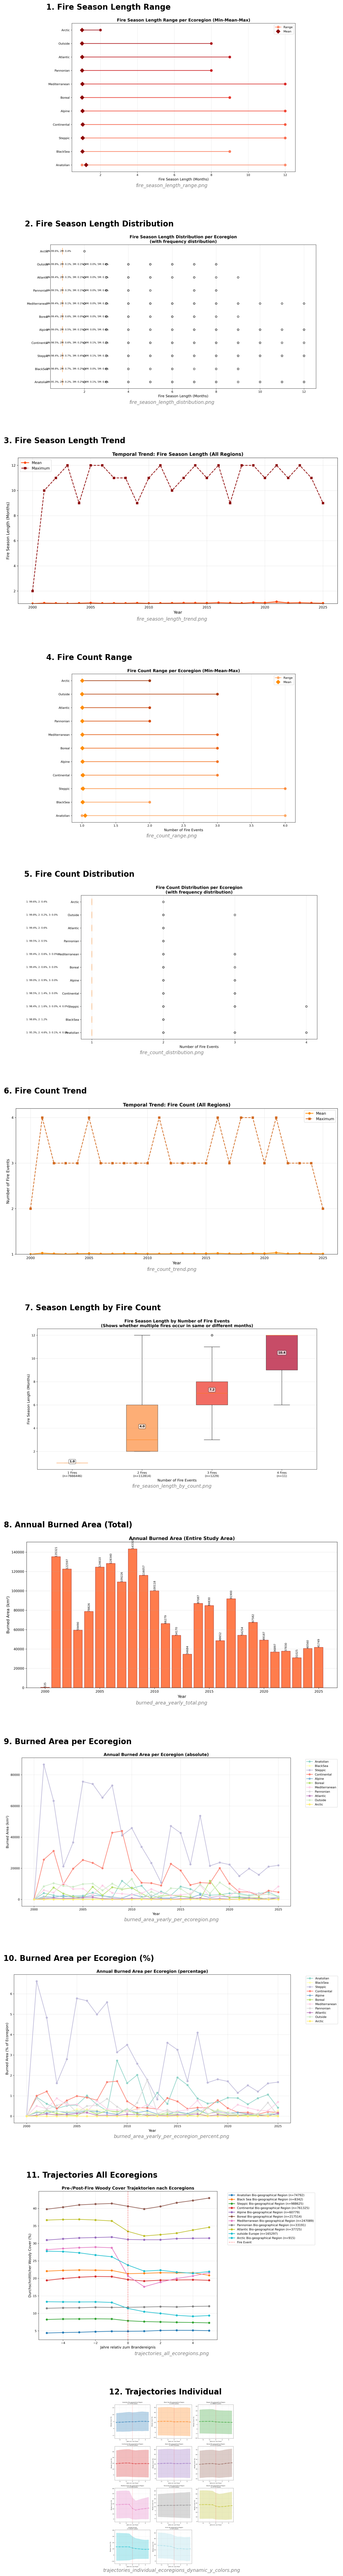


Viewer closed.


In [24]:
"""
Display all plots in full size, stacked vertically
"""

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

# Configuration
workDir = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"
output_dir = os.path.join(workDir, "_Runs", "04_Ecoregions_MBA")

# List of all plot files in order
plot_files = [
    ("Fire Season Length Range", "fire_season_length_range.png"),
    ("Fire Season Length Distribution", "fire_season_length_distribution.png"),
    ("Fire Season Length Trend", "fire_season_length_trend.png"),
    ("Fire Count Range", "fire_count_range.png"),
    ("Fire Count Distribution", "fire_count_distribution.png"),
    ("Fire Count Trend", "fire_count_trend.png"),
    ("Season Length by Fire Count", "fire_season_length_by_count.png"),
    ("Annual Burned Area (Total)", "burned_area_yearly_total.png"),
    ("Burned Area per Ecoregion", "burned_area_yearly_per_ecoregion.png"),
    ("Burned Area per Ecoregion (%)", "burned_area_yearly_per_ecoregion_percent.png"),
    ("Trajectories All Ecoregions", "trajectories_all_ecoregions.png"),
    ("Trajectories Individual", "trajectories_individual_ecoregions_dynamic_y_colors.png")
]

# Check which files exist
existing_plots = []
missing_plots = []

for title, filename in plot_files:
    plot_path = os.path.join(output_dir, filename)
    if os.path.exists(plot_path):
        existing_plots.append((title, filename, plot_path))
    else:
        missing_plots.append((title, filename))

print("=" * 80)
print("FULL-SIZE PLOT VIEWER - ALL PLOTS STACKED VERTICALLY")
print("=" * 80)
print(f"\nFound {len(existing_plots)} plots")

if missing_plots:
    print(f"\nMissing {len(missing_plots)} plots:")
    for title, filename in missing_plots:
        print(f"  - {title}: {filename}")

if not existing_plots:
    print("\nNo plots found in the output directory!")
    print(f"Directory: {output_dir}")
    exit()

# Create figure with stacked subplots
print("\nCreating stacked plot visualization...")
print("(This may take a moment to load all images)")

# Calculate figure height based on number of plots
fig_height = len(existing_plots) * 8  # 8 inches per plot

fig = plt.figure(figsize=(18, fig_height))
gs = GridSpec(len(existing_plots), 1, figure=fig, hspace=0.3)

# Load and display each plot
for i, (title, filename, filepath) in enumerate(existing_plots):
    print(f"  Loading [{i+1}/{len(existing_plots)}]: {title}")
    
    ax = fig.add_subplot(gs[i])
    
    try:
        img = mpimg.imread(filepath)
        ax.imshow(img)
        ax.axis('off')
        
        # Add title with plot number
        ax.set_title(f"{i+1}. {title}", 
                    fontsize=16, 
                    fontweight='bold', 
                    pad=15,
                    loc='left')
        
        # Add filename as subtitle
        ax.text(0.5, -0.02, filename, 
               transform=ax.transAxes,
               fontsize=10,
               ha='center',
               style='italic',
               color='gray')
    
    except Exception as e:
        ax.text(0.5, 0.5, f"Error loading: {filename}\n{str(e)}", 
               ha='center', va='center',
               fontsize=12, color='red')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

plt.tight_layout()

print("\n" + "=" * 80)
print("DISPLAYING ALL PLOTS")
print("=" * 80)
print("\nControls:")
print("  - Use mouse wheel to scroll")
print("  - Close window to exit")
print("=" * 80)

plt.show()

print("\nViewer closed.")

In [25]:
# === INDIVIDUAL TRAJECTORIES PER ECOREGION BY FIRE COUNT ===

print("\n13. CREATE INDIVIDUAL TRAJECTORIES BY FIRE COUNT")
print("-" * 70)

def calc_trajectory_by_fire_count(woody, burned, eco_mask, years_woody, years_burned, nodata, fire_count_value):
    """
    Calculate trajectory for pixels with specific fire count
    """
    # Count fires per pixel
    fire_counts = np.sum(burned == 1, axis=0)
    specific_fire_mask = (fire_counts == fire_count_value) & eco_mask
    
    n_pixels = np.sum(specific_fire_mask)
    
    if n_pixels < 30:  # Minimum threshold
        return None
    
    # Index of fire year per pixel (use first fire for multiple fires)
    burned_year_idx = np.argmax(burned == 1, axis=0)
    
    trajectory = []
    trajectory_std = []
    
    for rel_year in range(-5, 6):  # -5 to +5
        offset = years_burned[0] - years_woody[0]  # 2000 - 1985 = 15
        woody_band = burned_year_idx + rel_year + offset
        
        # Valid pixels for this year
        valid_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            specific_fire_mask
        )
        
        if np.sum(valid_mask) == 0:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            continue
        
        # Extract values
        y_idx, x_idx = np.where(valid_mask)
        values = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        values = values[values != nodata]
        
        if len(values) > 0:
            trajectory.append(np.nanmean(values))
            trajectory_std.append(np.nanstd(values))
        else:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
    
    return {
        'trajectory': trajectory,
        'std': trajectory_std,
        'n_pixels': n_pixels
    }


# Calculate trajectories for each fire count (1-4) per ecoregion
print("\nCalculating trajectories by fire count...")

fire_count_trajectories = {}

for eco_id in tqdm(unique_eco_ids, desc="Ecoregions"):
    if eco_id not in ecoregion_results:
        continue
    
    eco_mask = (eco_raster == eco_id)
    eco_row = ecoregions_clipped[ecoregions_clipped[numeric_id_col] == eco_id]
    eco_code = eco_row['code'].iloc[0] if len(eco_row) > 0 else f"Region_{eco_id}"
    eco_name = ecoregion_results[eco_id]['name']
    
    fire_count_trajectories[eco_id] = {
        'code': eco_code,
        'name': eco_name,
        'by_count': {}
    }
    
    # Calculate for fire counts 1-4
    for fc in range(1, 5):
        result = calc_trajectory_by_fire_count(
            woody, burned, eco_mask, years_woody, years_burned, nodata, fc
        )
        
        if result is not None:
            fire_count_trajectories[eco_id]['by_count'][fc] = result
            print(f"  {eco_code} - Fire Count {fc}: {result['n_pixels']} pixels")

# === PLOT: INDIVIDUAL SUBPLOTS PER ECOREGION ===
print("\nCreating individual trajectory plots by fire count...")

n_regions = len([eco for eco in fire_count_trajectories.values() if eco['by_count']])
n_cols = 2
n_rows = int(np.ceil(n_regions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten() if n_regions > 1 else [axes]

# Colors for different fire counts
fire_count_colors = {
    1: '#1f77b4',  # Blue
    2: '#ff7f0e',  # Orange
    3: '#2ca02c',  # Green
    4: '#d62728'   # Red
}

plot_idx = 0

for eco_id, data in fire_count_trajectories.items():
    if not data['by_count']:
        continue
    
    ax = axes[plot_idx]
    
    # Plot each fire count trajectory
    for fc, traj_data in sorted(data['by_count'].items()):
        trajectory_arr = np.array(traj_data['trajectory'])
        std_arr = np.array(traj_data['std'])
        
        # Main line
        ax.plot(range(-5, 6), trajectory_arr, 
               marker='o', linewidth=2.5, 
               color=fire_count_colors[fc],
               label=f'{fc} Fire(s) (n={traj_data["n_pixels"]})',
               alpha=0.8)
        
        # Standard deviation shadow
        ax.fill_between(
            range(-5, 6),
            trajectory_arr - std_arr,
            trajectory_arr + std_arr,
            alpha=0.2,
            color=fire_count_colors[fc]
        )
    
    # Fire event line
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    
    # Labels and styling
    ax.set_title(f"{data['code']} - {data['name']}", 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire Event', fontsize=10)
    ax.set_ylabel('Woody Cover (%)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5.5, 5.5)
    
    plot_idx += 1

# Hide empty subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.suptitle('Pre-/Post-Fire Woody Cover Trajectories by Fire Count per Ecoregion', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

plot_traj_by_count = os.path.join(output_dir, "trajectories_by_fire_count_per_ecoregion.png")
plt.savefig(plot_traj_by_count, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Trajectories by fire count: {plot_traj_by_count}")

# === PLOT: COMBINED VIEW - ALL FIRE COUNTS IN ONE PLOT ===
print("\nCreating combined trajectory plot...")

fig, ax = plt.subplots(figsize=(16, 10))

# Plot trajectories for each ecoregion and fire count
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']

for eco_id, data in fire_count_trajectories.items():
    if not data['by_count']:
        continue
    
    eco_code = data['code']
    
    for fc, traj_data in sorted(data['by_count'].items()):
        trajectory_arr = np.array(traj_data['trajectory'])
        
        ax.plot(range(-5, 6), trajectory_arr,
               marker=markers[fc-1],
               linestyle=line_styles[fc-1],
               linewidth=2,
               label=f'{eco_code} - {fc} Fire(s) (n={traj_data["n_pixels"]})',
               alpha=0.7)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2.5, alpha=0.6, label='Fire Event')
ax.set_xlabel('Years Relative to Fire Event', fontsize=13)
ax.set_ylabel('Woody Cover (%)', fontsize=13)
ax.set_title('Pre-/Post-Fire Trajectories: All Ecoregions by Fire Count', 
            fontsize=15, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5.5, 5.5)

plt.tight_layout()

plot_traj_combined = os.path.join(output_dir, "trajectories_all_ecoregions_by_fire_count.png")
plt.savefig(plot_traj_combined, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Combined trajectories: {plot_traj_combined}")

# === SAVE RESULTS AS CSV ===
print("\nSaving trajectory data by fire count...")

traj_by_count_data = []

for eco_id, data in fire_count_trajectories.items():
    for fc, traj_data in data['by_count'].items():
        for rel_year, (mean_val, std_val) in enumerate(zip(
            traj_data['trajectory'], 
            traj_data['std']
        ), start=-5):
            traj_by_count_data.append({
                'Ecoregion_ID': eco_id,
                'Ecoregion_Code': data['code'],
                'Ecoregion_Name': data['name'],
                'Fire_Count': fc,
                'N_Pixels': traj_data['n_pixels'],
                'Rel_Year': rel_year,
                'Woody_Cover_Mean': mean_val,
                'Woody_Cover_Std': std_val
            })

traj_by_count_df = pd.DataFrame(traj_by_count_data)
traj_by_count_csv = os.path.join(output_dir, "trajectories_by_fire_count.csv")
traj_by_count_df.to_csv(traj_by_count_csv, index=False)
print(f"✓ Trajectory data saved: {traj_by_count_csv}")

# === SUMMARY STATISTICS ===
print("\n" + "="*70)
print("TRAJECTORY ANALYSIS BY FIRE COUNT - SUMMARY")
print("="*70)

for eco_id, data in fire_count_trajectories.items():
    if not data['by_count']:
        continue
    
    print(f"\n{data['code']} - {data['name']}:")
    for fc in sorted(data['by_count'].keys()):
        traj_data = data['by_count'][fc]
        trajectory_arr = np.array(traj_data['trajectory'])
        
        # Calculate recovery metrics
        pre_fire = np.nanmean(trajectory_arr[:5])  # -5 to -1
        post_fire = trajectory_arr[5]  # Year 0
        recovery_5yr = trajectory_arr[-1]  # Year +5
        
        loss = pre_fire - post_fire if not np.isnan(post_fire) else np.nan
        recovery_pct = ((recovery_5yr - post_fire) / loss * 100) if loss > 0 and not np.isnan(recovery_5yr) else np.nan
        
        print(f"  Fire Count {fc} (n={traj_data['n_pixels']} pixels):")
        print(f"    Pre-fire avg: {pre_fire:.1f}%")
        print(f"    Immediate loss: {loss:.1f}%")
        print(f"    Recovery after 5 years: {recovery_pct:.1f}%" if not np.isnan(recovery_pct) else "    Recovery: N/A")

print("\n" + "="*70)
print("✓✓✓ TRAJECTORY ANALYSIS BY FIRE COUNT COMPLETED! ✓✓✓")
print("="*70)
print(f"\nCreated Files:")
print(f"  - {plot_traj_by_count}")
print(f"  - {plot_traj_combined}")
print(f"  - {traj_by_count_csv}")
print("="*70)


13. CREATE INDIVIDUAL TRAJECTORIES BY FIRE COUNT
----------------------------------------------------------------------

Calculating trajectories by fire count...


Ecoregions:   0%|          | 0/11 [00:00<?, ?it/s]

  Anatolian - Fire Count 1: 74792 pixels
  Anatolian - Fire Count 2: 27563 pixels
  Anatolian - Fire Count 3: 14772 pixels


Ecoregions:   9%|▉         | 1/11 [02:01<20:18, 121.80s/it]

  Anatolian - Fire Count 4: 9544 pixels
  BlackSea - Fire Count 1: 8342 pixels
  BlackSea - Fire Count 2: 2987 pixels
  BlackSea - Fire Count 3: 1644 pixels


...

  Atlantic - Fire Count 4: 454 pixels
  Outside - Fire Count 1: 165297 pixels
  Outside - Fire Count 2: 62638 pixels
  Outside - Fire Count 3: 37407 pixels


Ecoregions:  91%|█████████ | 10/11 [19:52<01:58, 118.89s/it]

  Outside - Fire Count 4: 24589 pixels
  Arctic - Fire Count 1: 915 pixels


Ecoregions: 100%|██████████| 11/11 [20:40<00:00, 112.78s/it]



Creating individual trajectory plots by fire count...
✓ Trajectories by fire count: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\trajectories_by_fire_count_per_ecoregion.png

Creating combined trajectory plot...
✓ Combined trajectories: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\trajectories_all_ecoregions_by_fire_count.png

Saving trajectory data by fire count...
✓ Trajectory data saved: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\trajectories_by_fire_count.csv

TRAJECTORY ANALYSIS BY FIRE COUNT - SUMMARY

Anatolian - Anatolian Bio-geographical Region:
  Fire Count 1 (n=74792 pixels):
    Pre-fire avg: 4.6%
    Immediate loss: -0.2%
    Recovery: N/A
  Fire Count 2 (n=27563 pixels):
    Pre-fire avg: 3.9%
    Immediate loss: -0.2%
    Recovery: N/A
  Fire Count 3 (n=14772 pixels):
    Pre-fire avg: 3.8%
    Immediate loss: -0.3%
    Recovery: N/A
  Fire Count 4 (n=9544 pixels):
    Pre-fire avg: 3.

In [27]:
# === 14. RECOVERY RATE COMPARISON (UPDATED) ===

print("\n14. RECOVERY RATE COMPARISON BY FIRE COUNT (EXTENDED)")
print("-" * 70)

def calc_trajectory_by_fire_count_extended(woody, burned, eco_mask, years_woody, years_burned, nodata, fire_count_value):
    """
    Calculate extended trajectory for pixels with specific fire count (-5 to +10 years)
    """
    fire_counts = np.sum(burned == 1, axis=0)
    specific_fire_mask = (fire_counts == fire_count_value) & eco_mask
    
    n_pixels = np.sum(specific_fire_mask)
    
    if n_pixels < 30:
        return None
    
    burned_year_idx = np.argmax(burned == 1, axis=0)
    
    trajectory = []
    trajectory_std = []
    
    for rel_year in range(-5, 11):  # -5 to +10
        offset = years_burned[0] - years_woody[0]
        woody_band = burned_year_idx + rel_year + offset
        
        valid_mask = (
            (woody_band >= 0) &
            (woody_band < len(years_woody)) &
            specific_fire_mask
        )
        
        if np.sum(valid_mask) == 0:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            continue
        
        y_idx, x_idx = np.where(valid_mask)
        values = woody[woody_band[y_idx, x_idx], y_idx, x_idx]
        values = values[values != nodata]
        
        if len(values) > 0:
            trajectory.append(np.nanmean(values))
            trajectory_std.append(np.nanstd(values))
        else:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
    
    return {
        'trajectory': trajectory,
        'std': trajectory_std,
        'n_pixels': n_pixels
    }

# Recalculate trajectories with extended time period
print("\nRecalculating extended trajectories (10 years post-fire)...")

extended_trajectories = {}

for eco_id in tqdm(unique_eco_ids, desc="Extended Trajectories"):
    if eco_id not in ecoregion_results:
        continue
    
    eco_mask = (eco_raster == eco_id)
    eco_row = ecoregions_clipped[ecoregions_clipped[numeric_id_col] == eco_id]
    eco_code = eco_row['code'].iloc[0] if len(eco_row) > 0 else f"Region_{eco_id}"
    
    extended_trajectories[eco_id] = {
        'code': eco_code,
        'by_count': {}
    }
    
    for fc in range(1, 5):
        result = calc_trajectory_by_fire_count_extended(
            woody, burned, eco_mask, years_woody, years_burned, nodata, fc
        )
        
        if result is not None:
            extended_trajectories[eco_id]['by_count'][fc] = result

# Calculate extended recovery data
recovery_data_extended = []

for eco_id, data in extended_trajectories.items():
    for fc, traj_data in data['by_count'].items():
        trajectory_arr = np.array(traj_data['trajectory'])
        
        pre_fire = np.nanmean(trajectory_arr[:5])  # -5 to -1
        fire_year = trajectory_arr[5]  # Year 0
        
        # Recovery at different time points (1-10 years)
        for years_after in range(1, 11):
            if 5 + years_after < len(trajectory_arr):
                recovery_val = trajectory_arr[5 + years_after]
                loss = pre_fire - fire_year
                recovery_pct = ((recovery_val - fire_year) / loss * 100) if loss > 0 else np.nan
                
                recovery_data_extended.append({
                    'Ecoregion_Code': data['code'],
                    'Fire_Count': fc,
                    'N_Pixels': traj_data['n_pixels'],
                    'Years_After_Fire': years_after,
                    'Pre_Fire_Cover': pre_fire,
                    'Fire_Year_Cover': fire_year,
                    'Recovery_Cover': recovery_val,
                    'Woody_Loss': loss,
                    'Recovery_Percent': recovery_pct
                })

recovery_df_extended = pd.DataFrame(recovery_data_extended)

# Plot extended recovery rates with dynamic y-axis
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for fc_idx, fc in enumerate([1, 2, 3, 4]):
    ax = axes[fc_idx // 2, fc_idx % 2]
    
    fc_data = recovery_df_extended[recovery_df_extended['Fire_Count'] == fc]
    
    # Determine y-axis limits based on actual data
    all_recovery_values = fc_data['Recovery_Percent'].values
    y_min = np.nanmin(all_recovery_values) - 10 if len(all_recovery_values) > 0 else -50
    y_max = np.nanmax(all_recovery_values) + 10 if len(all_recovery_values) > 0 else 150
    
    # Ensure range includes at least -50 to 120
    y_min = min(y_min, -50)
    y_max = max(y_max, 120)
    
    for eco_code in fc_data['Ecoregion_Code'].unique():
        eco_data = fc_data[fc_data['Ecoregion_Code'] == eco_code]
        ax.plot(eco_data['Years_After_Fire'], 
               eco_data['Recovery_Percent'],
               marker='o', linewidth=2.5, markersize=8, 
               label=f"{eco_code} (n={eco_data['N_Pixels'].iloc[0]})", 
               alpha=0.85)
    
    # Reference lines
    ax.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.6, label='Full Recovery (100%)')
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='No Recovery (0%)')
    
    ax.set_xlabel('Years After Fire', fontsize=12)
    ax.set_ylabel('Recovery (%)', fontsize=12)
    ax.set_title(f'Recovery Rate: {fc} Fire Event(s)', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(range(1, 11))
    
    # Add horizontal grid lines at key percentages
    for pct in [0, 25, 50, 75, 100]:
        if y_min <= pct <= y_max:
            ax.axhline(y=pct, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.suptitle('Woody Cover Recovery Rates by Fire Count (Extended to 10 Years)', 
            fontsize=16, fontweight='bold')
plt.tight_layout()

plot_recovery_extended = os.path.join(output_dir, "recovery_rates_by_fire_count_extended.png")
plt.savefig(plot_recovery_extended, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Extended recovery rates plot: {plot_recovery_extended}")

# === ADDITIONAL PLOT: ALL ECOREGIONS COMBINED PER FIRE COUNT ===
print("\nCreating combined recovery comparison...")

fig, ax = plt.subplots(figsize=(16, 9))

colors_fc = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
markers_eco = {'ALP': 'o', 'ATL': 's', 'CON': '^', 'MED': 'D'}

# Determine overall y-axis limits
all_values = recovery_df_extended['Recovery_Percent'].values
y_min = np.nanmin(all_values) - 10 if len(all_values) > 0 else -50
y_max = np.nanmax(all_values) + 10 if len(all_values) > 0 else 150
y_min = min(y_min, -50)
y_max = max(y_max, 120)

for fc in [1, 2, 3, 4]:
    fc_data = recovery_df_extended[recovery_df_extended['Fire_Count'] == fc]
    
    for eco_code in fc_data['Ecoregion_Code'].unique():
        eco_data = fc_data[fc_data['Ecoregion_Code'] == eco_code]
        marker = markers_eco.get(eco_code, 'o')
        
        ax.plot(eco_data['Years_After_Fire'], 
               eco_data['Recovery_Percent'],
               marker=marker, 
               linewidth=2, 
               markersize=7,
               color=colors_fc[fc],
               label=f'{eco_code} - {fc}F (n={eco_data["N_Pixels"].iloc[0]})',
               alpha=0.8)

ax.axhline(y=100, color='green', linestyle='--', linewidth=2.5, alpha=0.6, label='Full Recovery')
ax.axhline(y=0, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='No Recovery')

ax.set_xlabel('Years After Fire', fontsize=13)
ax.set_ylabel('Recovery (%)', fontsize=13)
ax.set_title('Woody Cover Recovery: All Ecoregions by Fire Count (10 Years)', 
            fontsize=15, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 10.5)
ax.set_ylim(y_min, y_max)
ax.set_xticks(range(1, 11))

# Add shaded regions
ax.axhspan(100, y_max, alpha=0.1, color='green', label='Above Pre-Fire')
ax.axhspan(0, 100, alpha=0.05, color='yellow', label='Partial Recovery')
ax.axhspan(y_min, 0, alpha=0.1, color='red', label='Further Degradation')

plt.tight_layout()

plot_recovery_combined = os.path.join(output_dir, "recovery_rates_all_combined_extended.png")
plt.savefig(plot_recovery_combined, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Combined recovery plot: {plot_recovery_combined}")

# Save extended recovery data
recovery_csv_extended = os.path.join(output_dir, "recovery_rates_by_fire_count_extended.csv")
recovery_df_extended.to_csv(recovery_csv_extended, index=False)
print(f"✓ Extended recovery data saved: {recovery_csv_extended}")

# === SUMMARY STATISTICS ===
print("\n" + "="*70)
print("EXTENDED RECOVERY ANALYSIS SUMMARY (10 YEARS)")
print("="*70)

for fc in [1, 2, 3, 4]:
    print(f"\n{fc} FIRE EVENT(S):")
    fc_data = recovery_df_extended[recovery_df_extended['Fire_Count'] == fc]
    
    for eco_code in sorted(fc_data['Ecoregion_Code'].unique()):
        eco_data = fc_data[fc_data['Ecoregion_Code'] == eco_code]
        
        # 5-year and 10-year recovery
        rec_5yr = eco_data[eco_data['Years_After_Fire'] == 5]['Recovery_Percent'].values
        rec_10yr = eco_data[eco_data['Years_After_Fire'] == 10]['Recovery_Percent'].values
        
        print(f"  {eco_code}:")
        if len(rec_5yr) > 0:
            print(f"    5-year recovery: {rec_5yr[0]:.1f}%")
        if len(rec_10yr) > 0:
            print(f"    10-year recovery: {rec_10yr[0]:.1f}%")
            
            # Calculate recovery rate (% per year)
            if len(rec_5yr) > 0 and not np.isnan(rec_10yr[0]) and not np.isnan(rec_5yr[0]):
                rate = (rec_10yr[0] - rec_5yr[0]) / 5
                print(f"    Recovery rate (yr 5-10): {rate:.2f}%/year")

print("\n" + "="*70)
print("✓✓✓ EXTENDED RECOVERY ANALYSIS COMPLETED! ✓✓✓")
print("="*70)
print(f"\nCreated Files:")
print(f"  1. {plot_recovery_extended}")
print(f"  2. {plot_recovery_combined}")
print(f"  3. {recovery_csv_extended}")
print("="*70)


14. RECOVERY RATE COMPARISON BY FIRE COUNT (EXTENDED)
----------------------------------------------------------------------

Recalculating extended trajectories (10 years post-fire)...


Extended Trajectories: 100%|██████████| 11/11 [25:30<00:00, 139.13s/it]


✓ Extended recovery rates plot: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\recovery_rates_by_fire_count_extended.png

Creating combined recovery comparison...
✓ Combined recovery plot: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\recovery_rates_all_combined_extended.png
✓ Extended recovery data saved: \\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis\_Runs\04_Ecoregions_MBA\recovery_rates_by_fire_count_extended.csv

EXTENDED RECOVERY ANALYSIS SUMMARY (10 YEARS)

1 FIRE EVENT(S):
  Alpine:
    5-year recovery: 112.0%
    10-year recovery: 397.2%
    Recovery rate (yr 5-10): 57.02%/year
  Anatolian:
    5-year recovery: nan%
    10-year recovery: nan%
  Arctic:
    5-year recovery: -55.5%
    10-year recovery: 399.5%
    Recovery rate (yr 5-10): 91.01%/year
  Atlantic:
    5-year recovery: 36.2%
    10-year recovery: 70.3%
    Recovery rate (yr 5-10): 6.82%/year
  BlackSea:
    5-year recovery: -49.7%
    10-year recovery: -381.4%


In [1]:
# === 15. COMPREHENSIVE SUMMARY STATISTICS VISUALIZATION ===

print("\n15. CREATE COMPREHENSIVE SUMMARY STATISTICS PLOTS")
print("-" * 70)

# Calculate pixel area
pixel_area_km2 = 0.25  # 500m × 500m
pixel_area_ha = 25

# Calculate ecoregion total areas
eco_total_areas = {}
for eco_id, data in fire_count_trajectories.items():
    eco_mask = (eco_raster == eco_id)
    n_pixels = np.sum(eco_mask)
    eco_total_areas[eco_id] = n_pixels * pixel_area_km2

# Collect summary statistics
summary_stats = []

for eco_id, data in fire_count_trajectories.items():
    if not data['by_count']:
        continue
    
    eco_total_area = eco_total_areas[eco_id]
    
    for fc, traj_data in data['by_count'].items():
        trajectory_arr = np.array(traj_data['trajectory'])
        
        # Calculate metrics
        pre_fire = np.nanmean(trajectory_arr[:5])  # -5 to -1
        post_fire = trajectory_arr[5]  # Year 0
        recovery_5yr = trajectory_arr[-1]  # Year +5
        
        loss = pre_fire - post_fire if not np.isnan(post_fire) else np.nan
        recovery_pct = ((recovery_5yr - post_fire) / loss * 100) if loss > 0 and not np.isnan(recovery_5yr) else np.nan
        
        # Convert pixels to area
        area_km2 = traj_data['n_pixels'] * pixel_area_km2
        area_ha = traj_data['n_pixels'] * pixel_area_ha
        percent_of_ecoregion = (area_km2 / eco_total_area * 100) if eco_total_area > 0 else 0
        
        summary_stats.append({
            'Ecoregion_ID': eco_id,
            'Ecoregion_Code': data['code'],
            'Ecoregion_Name': data['name'],
            'Fire_Count': fc,
            'N_Pixels': traj_data['n_pixels'],
            'Area_km2': area_km2,
            'Area_ha': area_ha,
            'Percent_of_Ecoregion': percent_of_ecoregion,
            'Ecoregion_Total_km2': eco_total_area,
            'Pre_Fire_Cover': pre_fire,
            'Post_Fire_Cover': post_fire,
            'Recovery_5yr_Cover': recovery_5yr,
            'Woody_Loss': loss,
            'Recovery_Percent': recovery_pct
        })

summary_df = pd.DataFrame(summary_stats)

# Save summary statistics
summary_csv = os.path.join(output_dir, "summary_statistics_by_fire_count.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"✓ Summary statistics saved: {summary_csv}")

# === PLOT 1: AFFECTED AREA BY FIRE COUNT ===
print("\nCreating affected area plots...")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1a) Absolute area (km²) by fire count and ecoregion
ax1 = axes[0, 0]
eco_codes = summary_df['Ecoregion_Code'].unique()
fire_counts = sorted(summary_df['Fire_Count'].unique())
x = np.arange(len(eco_codes))
width = 0.2

colors_fc = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}

for i, fc in enumerate(fire_counts):
    fc_data = summary_df[summary_df['Fire_Count'] == fc]
    areas = [fc_data[fc_data['Ecoregion_Code'] == eco]['Area_km2'].values[0] 
             if len(fc_data[fc_data['Ecoregion_Code'] == eco]) > 0 else 0 
             for eco in eco_codes]
    
    offset = (i - len(fire_counts)/2 + 0.5) * width
    bars = ax1.bar(x + offset, areas, width, label=f'{fc} Fire(s)', 
                   color=colors_fc[fc], alpha=0.8)
    
    # Add value labels
    for bar, area in zip(bars, areas):
        if area > 0:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{area:.1f}',
                    ha='center', va='bottom', fontsize=8, rotation=90)

ax1.set_xlabel('Ecoregion', fontsize=12)
ax1.set_ylabel('Affected Area (km²)', fontsize=12)
ax1.set_title('Affected Area by Fire Count per Ecoregion (Absolute)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(eco_codes, rotation=0)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 1b) Percentage of ecoregion area
ax2 = axes[0, 1]

for i, fc in enumerate(fire_counts):
    fc_data = summary_df[summary_df['Fire_Count'] == fc]
    percents = [fc_data[fc_data['Ecoregion_Code'] == eco]['Percent_of_Ecoregion'].values[0] 
                if len(fc_data[fc_data['Ecoregion_Code'] == eco]) > 0 else 0 
                for eco in eco_codes]
    
    offset = (i - len(fire_counts)/2 + 0.5) * width
    bars = ax2.bar(x + offset, percents, width, label=f'{fc} Fire(s)', 
                   color=colors_fc[fc], alpha=0.8)
    
    # Add value labels
    for bar, pct in zip(bars, percents):
        if pct > 0:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{pct:.1f}%',
                    ha='center', va='bottom', fontsize=8, rotation=90)

ax2.set_xlabel('Ecoregion', fontsize=12)
ax2.set_ylabel('Affected Area (% of Ecoregion)', fontsize=12)
ax2.set_title('Affected Area by Fire Count per Ecoregion (% of Region)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(eco_codes, rotation=0)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# 1c) Stacked area showing distribution across fire counts
ax3 = axes[1, 0]

for eco_idx, eco_code in enumerate(eco_codes):
    eco_data = summary_df[summary_df['Ecoregion_Code'] == eco_code].sort_values('Fire_Count')
    areas = eco_data['Area_km2'].values
    
    bottom = 0
    for fc, area in zip(eco_data['Fire_Count'].values, areas):
        ax3.bar(eco_idx, area, bottom=bottom, color=colors_fc[fc], 
               alpha=0.8, edgecolor='white', linewidth=1)
        if area > 5:  # Only show label if area is significant
            ax3.text(eco_idx, bottom + area/2, f'{fc}F\n{area:.0f}km²',
                    ha='center', va='center', fontsize=8, fontweight='bold')
        bottom += area
    
    # Add total on top
    ax3.text(eco_idx, bottom, f'{bottom:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_xlabel('Ecoregion', fontsize=12)
ax3.set_ylabel('Total Affected Area (km²)', fontsize=12)
ax3.set_title('Stacked Affected Area by Fire Count', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(eco_codes)))
ax3.set_xticklabels(eco_codes, rotation=0)
ax3.grid(axis='y', alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_fc[fc], alpha=0.8, label=f'{fc} Fire(s)') 
                  for fc in fire_counts]
ax3.legend(handles=legend_elements, fontsize=10, loc='upper right')

# 1d) Pie charts showing fire count distribution per ecoregion
ax4 = axes[1, 1]
ax4.axis('off')

n_ecos = len(eco_codes)
pie_positions = [(0.25, 0.75), (0.75, 0.75), (0.25, 0.25), (0.75, 0.25)][:n_ecos]

for idx, (eco_code, pos) in enumerate(zip(eco_codes, pie_positions)):
    eco_data = summary_df[summary_df['Ecoregion_Code'] == eco_code].sort_values('Fire_Count')
    
    # Create inset axes for pie chart
    pie_ax = fig.add_axes([pos[0]-0.12, pos[1]-0.12, 0.24, 0.24])
    
    areas = eco_data['Area_km2'].values
    labels = [f'{fc}F' for fc in eco_data['Fire_Count'].values]
    colors = [colors_fc[fc] for fc in eco_data['Fire_Count'].values]
    
    wedges, texts, autotexts = pie_ax.pie(areas, labels=labels, colors=colors,
                                           autopct='%1.1f%%', startangle=90,
                                           textprops={'fontsize': 8, 'fontweight': 'bold'})
    
    pie_ax.set_title(f'{eco_code}\n{sum(areas):.1f} km²', 
                    fontsize=10, fontweight='bold', pad=10)

plt.suptitle('Affected Area Analysis by Fire Count and Ecoregion', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_area_summary = os.path.join(output_dir, "summary_affected_areas.png")
plt.savefig(plot_area_summary, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Affected area summary: {plot_area_summary}")

# === PLOT 2: WOODY COVER METRICS ===
print("\nCreating woody cover metrics plots...")

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# 2a) Pre-fire woody cover by ecoregion and fire count
ax1 = axes[0]

for i, fc in enumerate(fire_counts):
    fc_data = summary_df[summary_df['Fire_Count'] == fc]
    pre_fire = [fc_data[fc_data['Ecoregion_Code'] == eco]['Pre_Fire_Cover'].values[0] 
                if len(fc_data[fc_data['Ecoregion_Code'] == eco]) > 0 else np.nan 
                for eco in eco_codes]
    
    offset = (i - len(fire_counts)/2 + 0.5) * width
    bars = ax1.bar(x + offset, pre_fire, width, label=f'{fc} Fire(s)', 
                   color=colors_fc[fc], alpha=0.8)
    
    # Add value labels
    for bar, val in zip(bars, pre_fire):
        if not np.isnan(val):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=8)

ax1.set_xlabel('Ecoregion', fontsize=12)
ax1.set_ylabel('Pre-Fire Woody Cover (%)', fontsize=12)
ax1.set_title('Pre-Fire Woody Cover by Fire Count per Ecoregion', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(eco_codes, rotation=0)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 100)

# 2b) Woody loss (absolute) by ecoregion and fire count
ax2 = axes[1]

for i, fc in enumerate(fire_counts):
    fc_data = summary_df[summary_df['Fire_Count'] == fc]
    losses = [fc_data[fc_data['Ecoregion_Code'] == eco]['Woody_Loss'].values[0] 
              if len(fc_data[fc_data['Ecoregion_Code'] == eco]) > 0 else np.nan 
              for eco in eco_codes]
    
    offset = (i - len(fire_counts)/2 + 0.5) * width
    bars = ax2.bar(x + offset, losses, width, label=f'{fc} Fire(s)', 
                   color=colors_fc[fc], alpha=0.8)
    
    # Add value labels
    for bar, loss in zip(bars, losses):
        if not np.isnan(loss):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{loss:.1f}%',
                    ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Ecoregion', fontsize=12)
ax2.set_ylabel('Immediate Woody Cover Loss (%)', fontsize=12)
ax2.set_title('Immediate Woody Cover Loss by Fire Count per Ecoregion', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(eco_codes, rotation=0)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(axis='y', alpha=0.3)

# 2c) Recovery after 5 years (%) by ecoregion and fire count
ax3 = axes[2]

for i, fc in enumerate(fire_counts):
    fc_data = summary_df[summary_df['Fire_Count'] == fc]
    recovery = [fc_data[fc_data['Ecoregion_Code'] == eco]['Recovery_Percent'].values[0] 
                if len(fc_data[fc_data['Ecoregion_Code'] == eco]) > 0 else np.nan 
                for eco in eco_codes]
    
    offset = (i - len(fire_counts)/2 + 0.5) * width
    bars = ax3.bar(x + offset, recovery, width, label=f'{fc} Fire(s)', 
                   color=colors_fc[fc], alpha=0.8)
    
    # Add value labels
    for bar, rec in zip(bars, recovery):
        if not np.isnan(rec):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{rec:.1f}%',
                    ha='center', va='bottom', fontsize=8)

# Add 100% reference line
ax3.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Full Recovery')

ax3.set_xlabel('Ecoregion', fontsize=12)
ax3.set_ylabel('Recovery after 5 Years (%)', fontsize=12)
ax3.set_title('Woody Cover Recovery (5 years) by Fire Count per Ecoregion', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(eco_codes, rotation=0)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(-20, 120)

plt.suptitle('Woody Cover Metrics by Fire Count and Ecoregion', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

plot_woody_metrics = os.path.join(output_dir, "summary_woody_cover_metrics.png")
plt.savefig(plot_woody_metrics, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Woody cover metrics: {plot_woody_metrics}")

# === PLOT 3: COMPREHENSIVE HEATMAP ===
print("\nCreating comprehensive heatmap...")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Prepare data for heatmaps
metrics = ['Area_km2', 'Percent_of_Ecoregion', 'Woody_Loss', 'Recovery_Percent']
titles = ['Affected Area (km²)', 'Affected Area (% of Region)', 
          'Woody Loss (%)', 'Recovery after 5 years (%)']
cmaps = ['YlOrRd', 'YlOrRd', 'Reds', 'RdYlGn']

for idx, (metric, title, cmap) in enumerate(zip(metrics, titles, cmaps)):
    ax = axes[idx // 2, idx % 2]
    
    # Create pivot table
    pivot_data = summary_df.pivot(index='Fire_Count', 
                                   columns='Ecoregion_Code', 
                                   values=metric)
    
    # Create heatmap
    im = ax.imshow(pivot_data.values, aspect='auto', cmap=cmap)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_xticklabels(pivot_data.columns)
    ax.set_yticklabels([f'{int(fc)} Fire(s)' for fc in pivot_data.index])
    
    # Add values as text
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            value = pivot_data.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value > np.nanmean(pivot_data.values) else 'black'
                if 'Area' in metric:
                    text = f'{value:.1f}'
                else:
                    text = f'{value:.1f}%'
                ax.text(j, i, text, ha='center', va='center', 
                       color=text_color, fontsize=10, fontweight='bold')
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Ecoregion', fontsize=11)
    ax.set_ylabel('Fire Count', fontsize=11)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

plt.suptitle('Comprehensive Summary Statistics Heatmap', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_heatmap = os.path.join(output_dir, "summary_heatmap.png")
plt.savefig(plot_heatmap, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Summary heatmap: {plot_heatmap}")

# === PLOT 4: FIRE COUNT DISTRIBUTION COMPARISON ===
print("\nCreating fire count distribution comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4a) Total area by fire count (all ecoregions combined)
ax1 = axes[0]
total_by_fc = summary_df.groupby('Fire_Count')['Area_km2'].sum()

bars = ax1.bar(total_by_fc.index, total_by_fc.values, 
               color=[colors_fc[fc] for fc in total_by_fc.index],
               alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels and percentages
total_area = total_by_fc.sum()
for bar, (fc, area) in zip(bars, total_by_fc.items()):
    height = bar.get_height()
    pct = (area / total_area * 100)
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{area:.1f} km²\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Number of Fire Events', fontsize=12)
ax1.set_ylabel('Total Affected Area (km²)', fontsize=12)
ax1.set_title('Total Affected Area by Fire Count (All Ecoregions)', 
             fontsize=13, fontweight='bold')
ax1.set_xticks(total_by_fc.index)
ax1.set_xticklabels([f'{int(fc)} Fire(s)' for fc in total_by_fc.index])
ax1.grid(axis='y', alpha=0.3)

# 4b) Percentage distribution per ecoregion
ax2 = axes[1]

for eco_code in eco_codes:
    eco_data = summary_df[summary_df['Ecoregion_Code'] == eco_code]
    fc_order = sorted(eco_data['Fire_Count'].values)
    percentages = []
    
    total_eco = eco_data['Area_km2'].sum()
    for fc in fire_counts:
        fc_area = eco_data[eco_data['Fire_Count'] == fc]['Area_km2'].values
        pct = (fc_area[0] / total_eco * 100) if len(fc_area) > 0 and total_eco > 0 else 0
        percentages.append(pct)
    
    ax2.plot(fire_counts, percentages, marker='o', linewidth=2.5, 
            markersize=10, label=eco_code, alpha=0.8)

ax2.set_xlabel('Number of Fire Events', fontsize=12)
ax2.set_ylabel('Percentage of Total Affected Area (%)', fontsize=12)
ax2.set_title('Fire Count Distribution per Ecoregion', 
             fontsize=13, fontweight='bold')
ax2.set_xticks(fire_counts)
ax2.set_xticklabels([f'{int(fc)}' for fc in fire_counts])
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()

plot_fc_distribution = os.path.join(output_dir, "summary_fire_count_distribution.png")
plt.savefig(plot_fc_distribution, dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Fire count distribution: {plot_fc_distribution}")

# === FINAL SUMMARY ===
print("\n" + "="*70)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*70)

print("\nAFFECTED AREAS:")
for eco_code in eco_codes:
    eco_data = summary_df[summary_df['Ecoregion_Code'] == eco_code]
    total_affected = eco_data['Area_km2'].sum()
    total_ecoregion = eco_data['Ecoregion_Total_km2'].iloc[0]
    pct_of_region = (total_affected / total_ecoregion * 100)
    
    print(f"\n{eco_code}:")
    print(f"  Total affected: {total_affected:.2f} km² ({total_affected*100:.0f} ha)")
    print(f"  Percentage of ecoregion: {pct_of_region:.2f}%")
    print(f"  Ecoregion total area: {total_ecoregion:.2f} km²")
    
    for _, row in eco_data.iterrows():
        print(f"    {row['Fire_Count']} Fire(s): {row['Area_km2']:.2f} km² ({row['Percent_of_Ecoregion']:.2f}% of region)")

print("\nWOODY COVER DYNAMICS:")
for eco_code in eco_codes:
    eco_data = summary_df[summary_df['Ecoregion_Code'] == eco_code]
    print(f"\n{eco_code}:")
    
    for _, row in eco_data.iterrows():
        print(f"  {row['Fire_Count']} Fire(s) ({row['Area_km2']:.1f} km²):")
        print(f"    Pre-fire cover: {row['Pre_Fire_Cover']:.1f}%")
        print(f"    Immediate loss: {row['Woody_Loss']:.1f}%")
        print(f"    Recovery (5yr): {row['Recovery_Percent']:.1f}%")

print("\n" + "="*70)
print("✓✓✓ COMPREHENSIVE SUMMARY VISUALIZATION COMPLETED! ✓✓✓")
print("="*70)
print(f"\nCreated Files:")
print(f"  1. {plot_area_summary}")
print(f"  2. {plot_woody_metrics}")
print(f"  3. {plot_heatmap}")
print(f"  4. {plot_fc_distribution}")
print(f"  5. {summary_csv}")
print("="*70)


15. CREATE COMPREHENSIVE SUMMARY STATISTICS PLOTS
----------------------------------------------------------------------


NameError: name 'fire_count_trajectories' is not defined